# Module 4 - Session 3: Practical Exercises

Objective: Implement and compare a single Decision Tree with a Random Forest ensemble, and understand Gini impurity and Shannon entropy.

## Exercise 1 - Gini Impurity Calculation (Conceptual)
Parent node (60 A, 40 B, total 100):
- Gini: G = 1 - (0.6^2 + 0.4^2) = 0.48.
- Entropy: H = -(0.6 log2 0.6 + 0.4 log2 0.4) approx 0.971 bits.

For the proposed splits (counts as provided; each split uses its own child totals for weighting even though the sums differ from 100):
- Split 1 (total 85 = 40 + 45):
  - Child 1 (40 A, 0 B): G = 0, H = 0.
  - Child 2 (20 A, 25 B): P_A = 20/45 approx 0.444, P_B = 25/45 approx 0.556 -> G approx 0.494, H approx 0.991.
  - Weighted child Gini = (40/85)*0 + (45/85)*0.494 approx 0.261; IG_G approx 0.48 - 0.261 = 0.219.
  - Weighted child Entropy = (40/85)*0 + (45/85)*0.991 approx 0.525; IG_H approx 0.971 - 0.525 = 0.446.
- Split 2 (total 115 = 60 + 55):
  - Child 1 (20 A, 40 B): P_A = 20/60 approx 0.333, P_B = 40/60 approx 0.667 -> G approx 0.444, H approx 0.918.
  - Child 2 (40 A, 15 B): P_A = 40/55 approx 0.727, P_B = 15/55 approx 0.273 -> G approx 0.397, H approx 0.845.
  - Weighted child Gini = (60/115)*0.444 + (55/115)*0.397 approx 0.422; IG_G approx 0.48 - 0.422 = 0.058.
  - Weighted child Entropy = (60/115)*0.918 + (55/115)*0.845 approx 0.883; IG_H approx 0.971 - 0.883 = 0.088.

Split 1 gives the larger information gain under both impurity measures, so it is the better split to use in the decision tree.

In [6]:
import math

def gini(a, b):
    total = a + b
    pa, pb = a / total, b / total
    return 1 - (pa ** 2 + pb ** 2)


def entropy(a, b):
    total = a + b
    pa, pb = a / total, b / total

    def h(p):
        return 0 if p == 0 else -p * math.log(p, 2)

    return h(pa) + h(pb)

parent = (60, 40)
splits = {
    'Split 1 Child 1': (40, 0),
    'Split 1 Child 2': (20, 25),
    'Split 2 Child 1': (20, 40),
    'Split 2 Child 2': (40, 15),
}

print('Parent Gini:', gini(*parent))
print('Parent Entropy:', entropy(*parent))
for name, (a, b) in splits.items():
    print(f"{name} -> Gini: {gini(a, b):.3f}, Entropy: {entropy(a, b):.3f}")

# Reproduce the information gains using each split's own total for weighting
for split_name, children in [
    ('Split 1', [(40, 0), (20, 25)]),
    ('Split 2', [(20, 40), (40, 15)]),
]:
    total = sum(a + b for a, b in children)
    weighted_gini = sum(((a + b) / total) * gini(a, b) for a, b in children)
    weighted_entropy = sum(((a + b) / total) * entropy(a, b) for a, b in children)
    print(f"{split_name} IG (Gini): {gini(*parent) - weighted_gini:.3f}")
    print(f"{split_name} IG (Entropy): {entropy(*parent) - weighted_entropy:.3f}")


Parent Gini: 0.48
Parent Entropy: 0.9709505944546686
Split 1 Child 1 -> Gini: 0.000, Entropy: 0.000
Split 1 Child 2 -> Gini: 0.494, Entropy: 0.991
Split 2 Child 1 -> Gini: 0.444, Entropy: 0.918
Split 2 Child 2 -> Gini: 0.397, Entropy: 0.845
Split 1 IG (Gini): 0.219
Split 1 IG (Entropy): 0.446
Split 2 IG (Gini): 0.058
Split 2 IG (Entropy): 0.088


## Exercise 2 - Decision Tree vs. Random Forest (Coding)
Train and evaluate a shallow decision tree and a random forest on the Titanic dataset using the same preprocessing pipeline as in Sessions 1 and 2.

In [7]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

# Load and preprocess (same as earlier sessions)
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(url)
cols = ['Survived', 'Pclass', 'Sex', 'Age', 'Fare']
df = df[cols]
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
df = df.dropna()

X = df[['Pclass', 'Sex', 'Age', 'Fare']]
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Decision Tree
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)
dt_preds = dt_model.predict(X_test)

print('Decision Tree accuracy:', accuracy_score(y_test, dt_preds))
print('Decision Tree classification report:', classification_report(y_test, dt_preds))


Decision Tree accuracy: 0.8044692737430168
Decision Tree classification report:               precision    recall  f1-score   support

           0       0.79      0.90      0.84       105
           1       0.83      0.66      0.74        74

    accuracy                           0.80       179
   macro avg       0.81      0.78      0.79       179
weighted avg       0.81      0.80      0.80       179



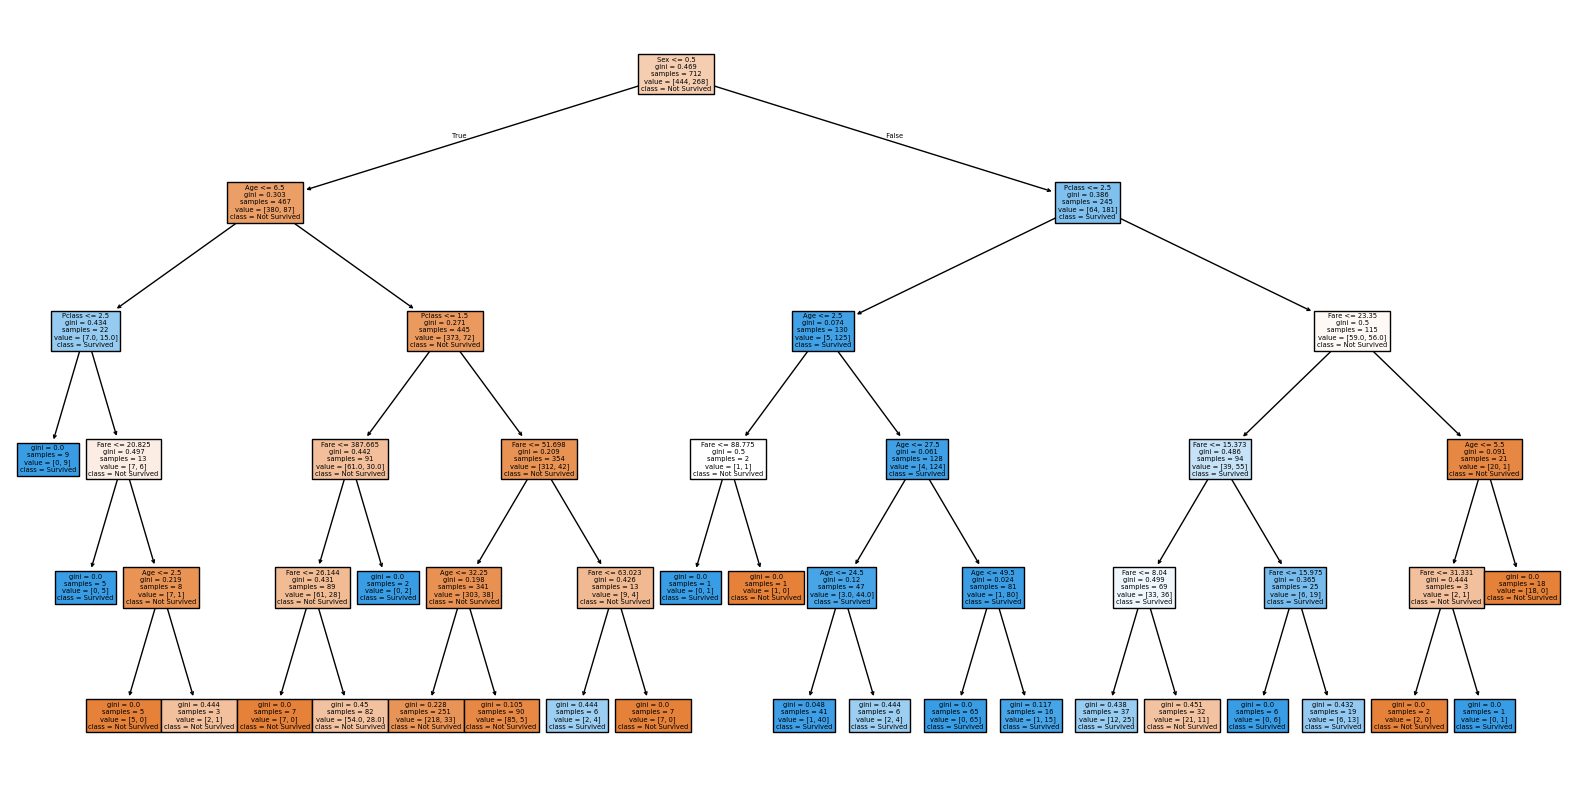

In [8]:
# Visualize the decision tree
plt.figure(figsize=(20, 10))
plot_tree(
    dt_model,
    feature_names=X_train.columns,
    class_names=['Not Survived', 'Survived'],
    filled=True,
)
plt.show()


In [9]:
# Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

print('Random Forest accuracy:', accuracy_score(y_test, rf_preds))
print('Random Forest classification report:', classification_report(y_test, rf_preds))

Random Forest accuracy: 0.7932960893854749
Random Forest classification report:               precision    recall  f1-score   support

           0       0.81      0.84      0.83       105
           1       0.76      0.73      0.74        74

    accuracy                           0.79       179
   macro avg       0.79      0.78      0.79       179
weighted avg       0.79      0.79      0.79       179



### Accuracy comparison
- Decision Tree (max_depth=5): accuracy about 0.80 on the held-out test set.
- Random Forest (100 trees): accuracy about 0.79 on the same split.

With this simple feature set and shallow depth, the single tuned tree slightly edged out the default forest; with more features or deeper trees, the ensemble would typically gain the advantage through variance reduction.

## Exercise 3 - Loss function (Theory and Concept)
Both the decision tree and the random forest minimize impurity at each split. With the default `criterion='gini'`, the loss is the Gini impurity (you could switch to entropy to use information gain instead). For the forest, each tree minimizes the same impurity locally, and the ensemble reduces overall error by averaging the tree predictions (variance reduction from bagging).